# Process data for histology sigs

<br>

* Process data for histology

* We only expect Epithelial, stromal, blastemal to have a transcriptomic signal. Regressive is not diagnostic and diffuse anaplasia had few samples.

<br>

<br>

Subset to:


* Wilms only

* No ribo

* Purity > 0.7

* Remove noisy small subsets?



<br>


Select kernel: Single Cell R (4.3)


In [1]:
##### ----- Load libraries
requiredPackages <- c("edgeR","GSEABase", "data.table", "limma", "cowplot", "ggplot2", "dplyr","Matrix", "singscore") #"Manu",ggscireadxl

for (pkg in requiredPackages){
  suppressWarnings(suppressMessages(library(pkg, character.only = T)))
}

#### ----- Plotting functions

MDS2gg <- function(DGE_x, col_str,col_pal=NULL, shape_str=NULL, shape_pal=NULL){

 # col_title <- str_to_title(col_str)
  col_title <- col_str
  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(DGE_x$samples[[col_str]])))
  }

  if (!(is.null(shape_str))){

    shape_title <- shape_str
    if (is.null(shape_pal)){
      shape_pal <- getShapes(unique(as.vector(DGE_x$samples[[shape_str]])))
    }

    MDS_dat <- limma::plotMDS(cpm(DGE_x, log=TRUE, prior.count = 2),
                              col=as.vector(col_pal[as.vector(DGE_x$samples[[col_str]])]),
                              pch=as.vector(shape_pal[as.vector(DGE_x$samples[[shape_str]])]),
                              cex = 1.6, cex.lab=0.8, cex.axis=0.6, tck=-0.02,mgp = c(1.5, 0.3, 0), plot=FALSE)
    plot_dat <- data.frame(ColBy=as.vector(DGE_x$samples[[col_str]]),
                           ShapeBy=as.vector(DGE_x$samples[[shape_str]]),
                           Dim1=MDS_dat$x,
                           Dim2=MDS_dat$y)
    ggplot(data=plot_dat, aes(x=Dim1, y=Dim2, color=ColBy, shape=ShapeBy))+geom_point(size=4)+
      scale_color_manual(name=col_title, values=col_pal)+scale_shape_manual(name=shape_title,values=shape_pal)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
            panel.grid.major = element_blank(),
            legend.direction = "vertical", legend.box = "vertical")
  } else {
    MDS_dat <- limma::plotMDS(cpm(DGE_x, log=TRUE, prior.count = 2),
                              col=as.vector(col_pal[as.vector(DGE_x$samples[[col_str]])]),
                              cex = 1.6, cex.lab=0.8, cex.axis=0.6, tck=-0.02,mgp = c(1.5, 0.3, 0), plot=FALSE)
    plot_dat <- data.frame(ColBy=as.vector(DGE_x$samples[[col_str]]),
                           Dim1=MDS_dat$x,
                           Dim2=MDS_dat$y)
    ggplot(data=plot_dat, aes(x=Dim1, y=Dim2, color=ColBy))+geom_point(size=4)+
      scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
            panel.grid.major = element_blank(),
            legend.direction = "vertical", legend.box = "vertical")
  }

}

ggRLE <- function(dat_x, annot, col_str, col_pal=NULL, isLog=TRUE,isLarge=FALSE,
                  ylim = c(-2,2),zero_line=TRUE, zero_col="skyblue", medPoint=FALSE, whisk=1.5){
 # dat_x <- LEGO_DGE_lst$CLONE$counts
 # annot <- annot_x
  #col_title <- str_to_title(col_str)
  col_title <- col_str
  if (!(setequal(colnames(dat_x), rownames(annot)))){
    message("Make sure annot rownames match dat_x sample names")
  }

  if (!(isLog)){
    dat_x <- log2(dat_x+1)
  }

  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(annot[[col_str]])))
  }

  ## Subset to common sample names
  annot <- annot[order(as.vector(annot[[col_str]])), , drop = F]
  annot$ColourBy <- as.vector(annot[[col_str]])
  annot$Sample <- rownames(annot)
  dat_x <- dat_x[, rownames(annot)]

  ## RLE boxplots
  rle <- dat_x - rowMedians(dat_x)
  rleLong <- reshape2::melt(rle, value.name = "RLE", varnames = c("genes", "Sample"))
  rleLong$Sample <- as.character(rleLong$Sample)

  rleLong <- merge(data.table::data.table(rleLong),  # faster merging
                   data.table::data.table(annot),
                   by = "Sample", sort=F)

  ## Calculate the median of the RLE boxplots:
  rleLong <- rleLong %>%
    group_by(Sample) %>%
    mutate(MedRLE = median(RLE)) %>%
    ungroup() %>%
    data.frame()
  rleLong$Sample <- factor(rleLong$Sample , levels=unique(rleLong$Sample))

  ## Remove Whiskers of the boxplots if the sample size is very large -- Sep's code
  if(isLarge){
    whisk=0
  }

  if (medPoint){
    gg <- ggplot(rleLong, aes(x = Sample, y = RLE, fill = ColourBy))+
      stat_boxplot(geom = "errorbar", width = 0.3)+
      geom_boxplot(outlier.shape = NA, coef=whisk)+
      geom_point(data = rleLong[! duplicated(rleLong$Sample), ],
                 aes(x = Sample, y = MedRLE, fill = ColourBy),
                 size = 2, shape = 21, colour = "black", lwd = 2)+
      scale_fill_manual(name=col_title,values = col_pal)+
      scale_y_continuous(name = "RLE",limits = ylim)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
          #  panel.grid.major = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.x = element_blank())
  } else {
    gg <- ggplot(rleLong, aes(x = Sample, y = RLE, fill = ColourBy))+
      stat_boxplot(geom = "errorbar", width = 0.3)+
      geom_boxplot(outlier.shape = NA,coef=whisk)+
      scale_fill_manual(name=col_title,values = col_pal)+
      scale_y_continuous(name = "RLE",limits = ylim)+theme_bw()+
      theme(panel.grid.minor = element_blank(),
          #  panel.grid.major = element_blank(),
            axis.ticks.x = element_blank(),
            axis.text.x = element_blank())
  }

  if (zero_line){
    gg <- gg + geom_hline(yintercept = 0, col = zero_col, lwd = 1)+
            theme(panel.grid.major=element_blank())
  }
  return(gg)
}

RLE2gg <- function(DGE_x, col_str, col_pal, geneLengths){

  if (is.na(geneLengths)){
    dat <- cpm(DGE_x, log=TRUE, prior.count = 1)
  } else {
    dat <- rpkm(DGE_x, log=TRUE, prior.count = 1, gene.length=geneLengths)
  }

  annot_x <- DGE_x$samples
  annot_x$Sample <- rownames(annot_x)
  # as.vector(DGE_x$samples[[col_str]])

  return(ggRLE(dat, annot_x, col_str, col_pal))

}


ggPCA <- function(dat_x, annot, col_str, col_pal=NULL,
                  shape_str=NULL, shape_pal=NULL,
                  IS_LOG=FALSE, CENTRE=TRUE,
                  SIZE=4, k=2, k_vec=c(1, 2), ...){

  if (!(setequal(colnames(dat_x), rownames(annot)))){
    message("Make sure annot rownames match dat_x sample names")
  }

  if (is.null(col_pal)){
    col_pal <- GetColPal(unique(as.vector(annot[[col_str]])))
  }

  ## Organise annotations
  annot$ColourBy <- as.vector(annot[[col_str]])
  annot$Sample <- rownames(annot)
  dat_x <- dat_x[, rownames(annot)]
  #col_title <- str_to_title(col_str)
  col_title <- col_str
    
  ## PCA
  PC_dat <- calc_pca(dat_x, is.log=IS_LOG, centre=CENTRE)

  ## Get plot data
  plot_dat <- as.data.frame(do.call(cbind,
                        lapply(1:k, function(x){PC_dat$sing.val$u[,x]})))
  colnames(plot_dat) <- paste0("PC", 1:k)
  plot_dat$Sample <- colnames(dat_x)

  plot_dat_merge <- merge(data.table::data.table(plot_dat),  # faster merging
                   data.table::data.table(annot),
                   by = "Sample", sort=F)

  if (k==2){
    k_x <- paste0("PC", k_vec[[1]])
    k_y <- paste0("PC", k_vec[[2]])
    plot_dat_merge$PC_x <- plot_dat_merge[[k_x]]
    plot_dat_merge$PC_y <-plot_dat_merge[[k_y]]

    if(!(is.null(shape_str))){
      plot_dat_merge$ShapeBy <- as.vector(plot_dat_merge[[shape_str]])
      #shape_title <- str_to_title(shape_str)
      shape_title <- shape_str
      if (is.null(shape_pal)){
        shape_pal <- getShapes(unique(as.vector(plot_dat_merge$ShapeBy)))
      }

      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy, shape=ShapeBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+
        scale_shape_manual(name=shape_title,values=shape_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=paste0(k_x," (", PC_dat$var[[k_vec[[1]]]],"%)"), y=paste0(k_y," (", PC_dat$var[[k_vec[[2]]]],"%)"))


    } else {
      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=paste0(k_x," (", PC_dat$var[[k_vec[[1]]]],"%)"), y=paste0(k_y," (", PC_dat$var[[k_vec[[2]]]],"%)"))
    }


  } else {


    gg_dat <- reshape2::melt(plot_dat, value.name="weight", id.vars="Sample", variable.name="PC")

    all_combinations <- combn(as.vector(unique(gg_dat$PC)),2)
    plot_lst <- lapply(1:ncol(all_combinations), function(i){
      k_x <- all_combinations[1, i]
      k_y <- all_combinations[2, i]
      plot_dat_merge$PC_x <- plot_dat_merge[[k_x]]
      plot_dat_merge$PC_y <-plot_dat_merge[[k_y]]

      ggplot(plot_dat_merge, aes(x=PC_x, y=PC_y, colour=ColourBy))+geom_point(size=SIZE)+
        scale_color_manual(name=col_title, values=col_pal)+theme_bw()+
        theme(panel.grid.minor = element_blank(),
              panel.grid.major = element_blank(),
              legend.direction = "vertical", legend.box = "vertical", ...)+
        labs(x=k_x, y=k_y)
    })
    names(plot_lst) <- unlist(lapply(1:ncol(all_combinations), function(i){
      paste0(all_combinations[1, i],"_vs_",all_combinations[2, i])}))

    ### Co-ordinate grid so that descending row is PC1->
    plot_lst_rows <- lapply(1:(k-1), function(row_j){
      plot_lst[names(plot_lst)[grepl(paste0("PC", row_j,"_vs"),names(plot_lst))]]
      })

    ### Add NULL plots
    plot_rows <- c()
    for (x in 1:length(plot_lst_rows)){
      numbNull <- k-1-length(plot_lst_rows[[x]])
      if (numbNull > 0){
        plot_rows <- c(plot_rows,vector(mode = 'list', length = numbNull),plot_lst_rows[[x]])
      } else {
        plot_rows <- c(plot_rows,plot_lst_rows[[x]])
      }}

    ## Add legend to bottom right
    my_leg <- get_legend(plot_rows[[1]])
    n_leg <- length(plot_rows)-length(plot_lst_rows)+1

    ## And remove legends
    plot_rows <- lapply(plot_rows, function(plot_x){plot_x+theme(legend.position = "none")})

    ## Plot!
    return(cowplot::plot_grid(plotlist=plot_rows,
                              ncol=k-1, nrow=length(plot_lst_rows), byrow=TRUE))
  }

}

calc_pca <- function(data, is.log, centre) {

  if(is.log == TRUE){
    data <- data
  }else{
    data <- log2(data + 1)
  }
  svd <- svd(apply(data, 1, function(x) scale(x, scale = FALSE, center = centre)))
  percent <- svd$d^2/sum(svd$d^2)*100
  percent <- sapply(seq_along(percent), function(i) {round(percent[i], 2)})
  return(list(sing.val = svd, var = percent))

}

getShapes <- function(vec){

  n = length(vec)

  if (n <= 12){
    shapes <- c(19,15,17,18,23,25,22,21,24,8,4,3)
  } else {
    shapes <- 1:25
  }

  shapes <- shapes[1:n]
  names(shapes) <- vec
  return(shapes)
}


GetColPal <- function(vec){
  
  pal <- gg_color_hue(as.integer(length(vec)))
  names(pal) <- vec
  return(pal)
}


gg_color_hue <- function(n) {
  hues = seq(15, 360, length = n)
  hcl(h = hues, l = 65, c = 100)[1:n]
}

fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }


##### ----- Get directories
raw_data_path = "/lustre/scratch125/cellgen/behjati/jp40/pipelines/6_RNA/data/counts/"
data_save_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/output/rna/"
sample_sheet_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/"
                   
sample_sheet_df = read.table(paste0(sample_sheet_dir,"driver_and_manifest_table_2026_07_03_pm.csv"), sep=",", skip=1, header=TRUE)
                   
         

<br>

### Load data 

-----

In [2]:
## -- Load data
counts_df <- read.table(paste0(data_save_dir, "combined_raw_counts.csv"), sep=",", header=TRUE,row.names=NULL)
counts_df <- counts_df[!grepl("^RP11-", counts_df$gene_name) &!grepl("^RPL", counts_df$gene_name),]

## -- Get library info
samples_r = read.table("ribozero.txt", sep="\t", header=FALSE)
samples_o = read.table("oligo.txt", sep="\t", header=FALSE)
missing_IDs <- setdiff(colnames(counts_df),c(samples_r$V1,samples_o$V1))
df_x = data.table(samples=c(samples_r$V1,samples_o$V1, missing_IDs),
          library=c(rep("ribo", length(samples_r$V1)), rep("oligo", length(samples_o$V1)), rep("NA", length(missing_IDs))))

## -- Get gene info
genes_df <- counts_df[,colnames(counts_df) %in% c("ensid", "gene_name"),]
rownames(genes_df) <- genes_df$ensid

## -- Prep data
rownames(counts_df) <- counts_df$ensid
counts_df <- counts_df[, !(colnames(counts_df) %in% c("ensid", "gene_name", "X"))]

## -- Get sample data
samples_df <- data.frame(sampleID = colnames(counts_df),
                                   library=as.vector(setNames(df_x$library, df_x$samples)[colnames(counts_df)]))

## -- Append more
cols_to_add <- c("Tumour.type", "Risk.category", "Event", "Outcome", "Outcome_qualifier", 
                 "sample_category", "Sample.type", "Age_at_diagnosis_months", "Sex", 
                 "Mets_at_ddx", "Predisposition", "Relapse_or_progression","Include_in_KB_Paper",
                "Event_free_survival", "Overall_survival", "Histology_of_this_specimen", "Contributor")

append_col <- function(col_x){return(as.vector(setNames(sample_sheet_df[[col_x]],
                                                  sample_sheet_df$RNA_ID)[colnames(counts_df)]))}

for (i in cols_to_add){
    samples_df[[i]] <- append_col(i)
}

## -- Add new group
x = samples_df[samples_df$Event %in% c("Relapse_alive", "Relapse_death"),]$sampleID
y = samples_df[samples_df$Outcome %in% c("Dead"),]$sampleID
z <- unique(c(x,y))
samples_df$all_outcome <- ifelse(samples_df$sampleID %in% z, "Bad", "Good")



In [3]:
## -- add purity
purity_df <- read.csv("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/purity_predisp.csv",
               header = TRUE, check.names = FALSE,stringsAsFactors = FALSE)

id_dict = setNames(sample_sheet_df$RNA_ID,sample_sheet_df$Sample)
purity_a_dict = setNames(purity_df$`Purity Estimate - ASCAT`, as.vector(id_dict[purity_df$DNA_ID]) )
purity_b_dict = setNames(purity_df$`Purity Estimate - Battenberg`, as.vector(id_dict[purity_df$DNA_ID]))

samples_df$purity <- as.vector(purity_a_dict[samples_df$sampleID])
samples_df$purity <- replace(samples_df$purity, samples_df$purity=="not_applicable", NA)
samples_df$purity  <- as.numeric(samples_df$purity)

Warning message:
“NAs introduced by coercion”


In [4]:
histology_cols <- setNames(c('#A8B9CB', '#4B5F6C', 
                            '#955F47', '#D9D9D9',
                            '#A7473A', '#7D9D33', '#B09B37', 
                            'black', '#ECE4D4'),
                          c('Diffuse anaplasia', 'Non anaplastic and variants', 
                            'Stromal', 'Mixed',
                            'Regressive', 'Blastemal', 'Epithelial', 
                            'Completely necrotic', 'Focal anaplasia'))

<br>

### Subset samples

In [5]:
## -- Subset to Wilms
samples_df <- samples_df[samples_df$Tumour.type == "Wilms",]

## -- Remove ribo
samples_df <- samples_df[!(samples_df$library %in% c("ribo")),]

## -- Remove low purity
samples_df <- samples_df[samples_df$purity > 0.6,]
samples_df <- samples_df[!(is.na(samples_df$purity)),]

## -- Remove irrelevant or too-small histologies
to_cut <- c("Nephroblastomatosis", "Completely necrotic",  
            "Focal anaplasia", "Mixed", "Non anaplastic and variants",
           "Diffuse anaplasia", "Regressive")
samples_df <- samples_df[!(samples_df$Histology_of_this_specimen %in% to_cut),]


## -- Subset
counts_df <- counts_df[,colnames(counts_df) %in% samples_df$sampleID]

In [6]:
table(samples_df$Histology_of_this_specimen)


 Blastemal Epithelial    Stromal 
        43         42         75 

<br>

### Make DGE

In [7]:
## -- rows are genes, columns are samples
wilms_dge <- edgeR::DGEList(counts_df,
               group = samples_df$Histology_of_this_specimen,#$Outcome,
               samples = samples_df,
               genes=genes_df)
              

<br>

<br>

### Process counts

-----

#### Drop noisy genes

In [8]:
annot <- wilms_dge$genes[match(rownames(wilms_dge), wilms_dge$genes$ensid), ]
drop <- grepl("^MT-|^RPL|^RPS|^MRPL|^MRPS", annot$gene_name) |
        grepl("^RN7SK|^RN7SL|^RNU[0-9]|^RNVU|^SNOR|^SCARNA|^MIR[0-9]",
              annot$gene_name) |
        grepl("^RNA5S|^RNA18S|^RNA28S|^RMRP|^RPPH1", annot$gene_name)
cat("dropping", sum(drop), "structural / small RNA genes\n")
wilms_dge <- wilms_dge[!drop, ]

dropping 5687 structural / small RNA genes


#### Remove extreme library sizes

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


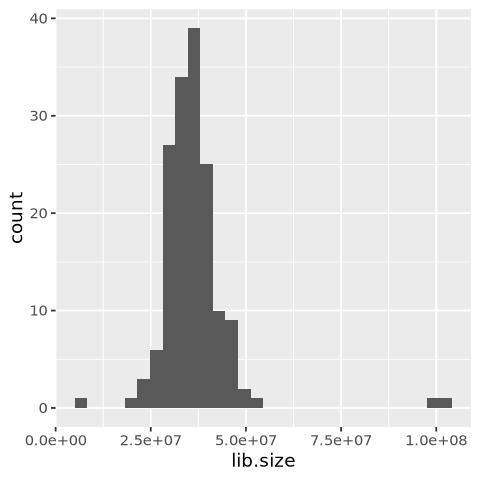

In [9]:
fig(4,4)
ggplot(data=wilms_dge$samples,aes(x=lib.size))+geom_histogram()

In [10]:
## -- minimum library size -- between 1 million and 100 million
wilms_dge <- wilms_dge[,(wilms_dge$samples$lib.size > 1e7) & (wilms_dge$samples$lib.size < 6e7) ] 

<br>

#### Remove lowly expressed genes

keep
FALSE  TRUE 
15270 14055 


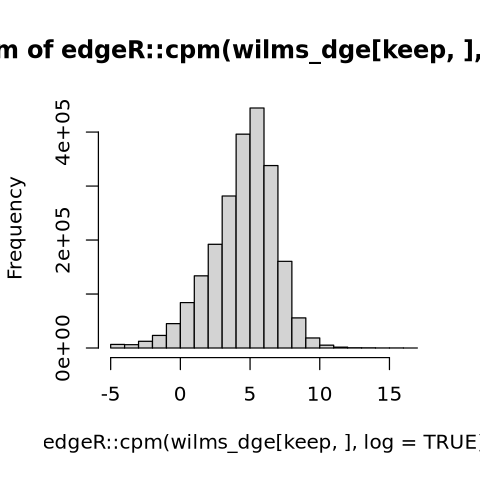

In [11]:
fig(4, 4)
keep = rowMeans(edgeR::cpm(y=wilms_dge, log = TRUE) >= 1) >= 0.3
#keep <- filterByExpr(wilms_dge)
hist(edgeR::cpm(wilms_dge[keep, ], log = TRUE))
print(table(keep))

In [12]:
wilms_dge <- wilms_dge[keep, ]

<br>

### Normalise

In [13]:
## -- Process counts
wilms_dge <- edgeR::calcNormFactors(wilms_dge, method="RLE")
wilms_dge$logCPM <- edgeR::cpm(wilms_dge, log=TRUE, prior.count = 1,
                             normalized.lib.sizes=TRUE, lib.size=wilms_dge$samples$lib.size)

<br>

### Processing for DGE analysis

In [14]:
## -- Design matrix
other_factor <- as.factor(wilms_dge$samples$Contributor)
purity_factor <- as.factor(wilms_dge$samples$purity)
group_factor <- as.factor(wilms_dge$samples$Histology_of_this_specimen)  # + Predisposition // Histology_of_this_specimen // Outcome
design_x <- model.matrix( ~0 +  group_factor)
wilms_dge$design <- design_x

## -- Estimate Dispersions
wilms_dge <- estimateDisp(wilms_dge, wilms_dge$design, robust=TRUE)

<br>

### Save

In [22]:
saveRDS(wilms_dge, file =paste0(data_save_dir,"objects/", "wilms_histology_dge.rds"))

<br>

<br>

## DE analysis


Histology contrasts were tested with limma-voom incorporating group-level quality weights (voomWithQualityWeights, var.group = histology), since the three histological groups differ substantially in transcriptional heterogeneity — stromal tumours in particular comprise several partially-penetrant component programmes — and edgeR's quasi-likelihood framework provides no equivalent variance weighting. 

-----

In [16]:
## -- Get contrasts

con <- makeContrasts(
  Blastemal_vs_rest = group_factorBlastemal - 0.5*group_factorEpithelial - 0.5*group_factorStromal,
  Epithelial_vs_rest = group_factorEpithelial - 0.5*group_factorBlastemal - 0.5*group_factorStromal,
  Stromal_vs_rest = group_factorStromal - 0.5*group_factorEpithelial - 0.5*group_factorBlastemal,
  levels = wilms_dge$design
)


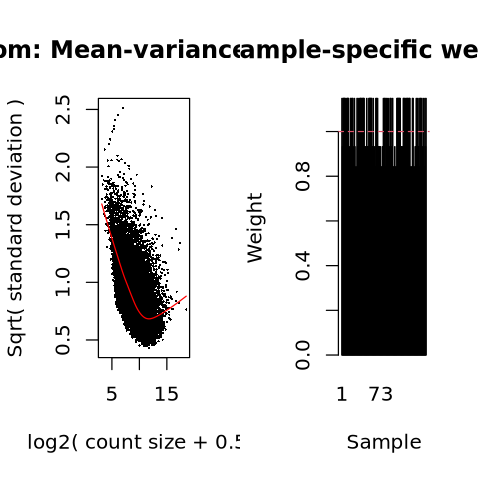

In [19]:
## -- voom with quality weights: NO calcNormFactors call, quantile normalization only
vwts <- voomWithQualityWeights(
  wilms_dge$counts,
  design = wilms_dge$design,
  normalize.method = "quantile",
    var.group = wilms_dge$samples$Histology_of_this_specimen,
  #  var.group = interaction(wilms_dge$samples$Contributor, wilms_dge$samples$Histology_of_this_specimen),
  plot = TRUE
)


In [20]:
## -- fit
fit <- lmFit(vwts, wilms_dge$design)
fit <- contrasts.fit(fit, con)
fit <- eBayes(fit, robust = TRUE)
fit_treat <- treat(fit, lfc = log2(1.5))
results_blast_voom <- topTable(fit, coef = "Blastemal_vs_rest", n = Inf, sort.by = "P")
results_treat <- topTreat(fit_treat, coef = "Blastemal_vs_rest", n = Inf, sort.by = "P")
summary(decideTests(fit_treat, adjust.method = "BH", p.value = 0.01))


       Blastemal_vs_rest Epithelial_vs_rest Stromal_vs_rest
Down                 176                 74            1009
NotSig             13380              13695           11915
Up                   499                286            1131

<br>

### Save

In [23]:
histology_list <- c("Blastemal", "Epithelial", "Stromal")
fdr_threshold <- 0.01

for (hist_x in histology_list) {
  coef_name <- paste0(hist_x, "_vs_rest")

  res_treat <- topTreat(fit_treat, coef = coef_name, n = Inf, sort.by = "P")
  res_treat$ensid <- rownames(res_treat)

  sig <- res_treat[res_treat$adj.P.Val < fdr_threshold, ]

  ## -- all significant genes (both directions), as Ensembl IDs
  writeLines(sig$ensid, file.path(data_save_dir, paste0("voom_treat_signature_", hist_x, ".txt")))

  ## -- split by direction
  writeLines(sig$ensid[sig$logFC > 0], file.path(data_save_dir,"signatures/", paste0("Histology_DE_up_", hist_x, ".txt")))
  writeLines(sig$ensid[sig$logFC < 0], file.path(data_save_dir,"signatures/", paste0("Histology_DE_down_", hist_x, ".txt")))

  cat(hist_x, ":", nrow(sig), "total significant (",
      sum(sig$logFC > 0), "up /", sum(sig$logFC < 0), "down )\n")
}

Blastemal : 675 total significant ( 499 up / 176 down )
Epithelial : 360 total significant ( 286 up / 74 down )
Stromal : 2140 total significant ( 1131 up / 1009 down )
